In [3]:
# --------------------------
# Configuration & Path Setup
# --------------------------

import pandas as pd
import numpy as np
import os
from pathlib import Path
from typing import Union, Optional

# Cross-platform path resolution (consistent with Iteration 0)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'raw_data': BASE_DIR / "Datasets" / "RW_Datasets",
    'iteration_output': BASE_DIR / "Datasets" / "Iteration_Outputs" / "_iteration_1",
    'embeddings': BASE_DIR / "Datasets" / "Embeddings" / "_iteration_1" / "bert-base-cased",
    'results': BASE_DIR / "Results" / "_iteration_1"
}

# Normalize all paths to absolute Path objects
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()

# Create output directories
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

# Data files configuration
DATA_FILES = {
    'df_14': PATHS['raw_data'] / "14k+ Reports RW_ACTUALS_PS.csv",
    'df_28': PATHS['raw_data'] / "28k+ Reports RW_ACTUALS_ALL.csv",
    'df_700': PATHS['raw_data'] / "700k+ Reports RW_ACTUALS_NH_OBS.csv"
}

def load_data(file_path: Union[str, Path], low_memory: bool = False) -> Optional[pd.DataFrame]:
    """
    Load CSV data into a DataFrame with error handling and encoding fallback.
    
    Parameters: 
        file_path (Union[str, Path]): Path to the CSV file
        low_memory (bool): Pass to pd.read_csv
        
    Returns:
        pandas.DataFrame: Loaded data or None if file not found
    """
    file_path = Path(file_path)  # Ensure it's a Path object
    
    # List of encodings to try
    encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, low_memory=low_memory, encoding=encoding, on_bad_lines='skip')
            print(f"Successfully loaded {file_path.name} ({len(df)} rows) [encoding: {encoding}]")
            return df
        except (UnicodeDecodeError, Exception):
            if encoding == encodings[-1]:
                # Last attempt: try with error handling
                try:
                    df = pd.read_csv(file_path, low_memory=low_memory, encoding=encoding, 
                                    errors='ignore', on_bad_lines='skip')
                    print(f"Successfully loaded {file_path.name} ({len(df)} rows) [encoding: {encoding} with errors='ignore']")
                    return df
                except Exception as final_error:
                    print(f"An error occurred while loading {file_path.name}: {final_error}")
                    return None
            continue
    
    return None

# Load Each File
RW_ACTUALS_PS = load_data(DATA_FILES['df_14'])
RW_ACTUALS_ALL = load_data(DATA_FILES['df_28'])
RW_ACTUALS_NH_OBS = load_data(DATA_FILES['df_700'])

# Check if all dataframes were loaded successfully
if all(df is not None for df in [RW_ACTUALS_PS, RW_ACTUALS_ALL, RW_ACTUALS_NH_OBS]):
    print("\n All files loaded successfully!")
else:
    print("\n Warning: Some files failed to load. Please check the file paths and try again.")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Successfully loaded 14k+ Reports RW_ACTUALS_PS.csv (14432 rows) [encoding: utf-8]
Successfully loaded 28k+ Reports RW_ACTUALS_ALL.csv (28323 rows) [encoding: utf-8]
Successfully loaded 700k+ Reports RW_ACTUALS_NH_OBS.csv (1069328 rows) [encoding: latin-1]

 All files loaded successfully!


In [8]:
# ---------------------------
# Clean DataFrames
# ---------------------------
def clean_df(df, subset_col='CASENO'):
    """
    Remove duplicates based on subset_col, keeping the first occurrence.
    """
    df_clean = df.drop_duplicates(subset=[subset_col], keep='last')
    return df_clean

# Clean the three dataframes
RW_ACTUALS_PS_clean = clean_df(RW_ACTUALS_PS)
RW_ACTUALS_ALL_clean = clean_df(RW_ACTUALS_ALL)
RW_ACTUALS_NH_OBS_clean = clean_df(RW_ACTUALS_NH_OBS)

# Rename columns in RW_ACTUALS_ALL_clean (not the original)
RW_ACTUALS_ALL_clean = RW_ACTUALS_ALL_clean.rename(columns={
    'EMPLOYMENT_CATEGORY': 'COMPANY_INVOLVED_TYPE',
    'HAZARD_PHYSICAL_SECURITY_EVENT': 'HAZARD',
    'COMPANY_NAME': 'COMPANY',
    'DATETIME': 'CASE_OCCURRENCE_DATE',
})

# Drop specified columns if they exist
columns_to_drop = ['ACTUAL_WORKDAYS_LTA', 'RETURNED_TO_WORK_DATE', 'PERSONAL_INJURIES', 
                   'OUTSIDE_LEGAL_INFLUENCE', 'COMPANY_TYPE', 'CASE_APPROVED_DATE']
existing_columns_to_drop = [col for col in columns_to_drop if col in RW_ACTUALS_ALL_clean.columns]
RW_ACTUALS_ALL_clean = RW_ACTUALS_ALL_clean.drop(columns=existing_columns_to_drop)

print(f"RW_ACTUALS_PS_clean shape: {RW_ACTUALS_PS_clean.shape}")
print(f"RW_ACTUALS_ALL_clean shape: {RW_ACTUALS_ALL_clean.shape}")
print(f"RW_ACTUALS_NH_OBS_clean shape: {RW_ACTUALS_NH_OBS_clean.shape}")

RW_ACTUALS_PS_clean shape: (895, 36)
RW_ACTUALS_ALL_clean shape: (23925, 36)
RW_ACTUALS_NH_OBS_clean shape: (21968, 36)


In [9]:
# ---------------------------
# Set Correct Data Types
# ---------------------------
def set_column_types(df):
    # Integer columns (remove decimals, coerce errors to NaN, then dropna if needed) ##CHECK
    int_cols = ['CASENO', 'LOCATION_SID', 'CASES_NO_OF_REGISTRATIONS']
    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    # Date columns (date only, not datetime)
    date_cols = [
        'CASE_OCCURENCE_DATE', 'CREATED_DATE', 'MODIFIED_DATE', 'CASE_CLOSED_DATE'
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce').dt.date

    # Datetime columns (keep full datetime)
    datetime_cols = ['VALID_FROM', 'VALID_TO']
    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Other columns as string (object) - preserve NaN values
    text_cols = [
        'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION',
        'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SHORT', 'COUNTRY_SHORT', 'SL_COUNTRY',
        'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4',
        'TITLE', 'COMPANY_INVOLVED_TYPE', 'CASE_TYPE', 'CASE_SEVERITY', 'CASE_DESCRIPTION',
        'STATUS', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'FULL_INVESTIGATION_DONE',
        'APPROVED_WITHIN_DEADLINE', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA',
        'LEARNINGS_ACTUAL_SEVERITY', 'LEARNINGS_POTENTIAL_RISK'
    ]
    for col in text_cols:
        if col in df.columns:
            # Convert to string but preserve NaN values (don't convert NaN to 'nan' string)
            df[col] = df[col].apply(lambda x: str(x) if pd.notna(x) else np.nan)

    return df

# Apply to each loaded DataFrame
RW_ACTUALS_PS = set_column_types(RW_ACTUALS_PS_clean)
RW_ACTUALS_ALL = set_column_types(RW_ACTUALS_ALL_clean)
RW_ACTUALS_NH_OBS = set_column_types(RW_ACTUALS_NH_OBS_clean)

/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_12699/180268276.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_12699/180268276.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_12699/180268276.py:9: SettingWithCopyWarning: 
A value is trying to

In [10]:
#--------------------------------------------------------------
# Replace Language-Specific Characters in DataFrames
#--------------------------------------------------------------

def replace_language_specific_chars(df):
    """
    Replace language-specific characters based on SL_COUNTRY.
    - German (Germany): Replace umlauts (ä, ö, ü) with (ae, oe, ue)
    - Swedish (Sweden): Replace å, ä, ö with a, a, o
    - Dutch (Netherlands): Replace ë, ï, ä, ö, ü with e, i, a, o, u
    """
    # Get text columns (object dtype)
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    def safe_replace(series, old, new):
        """Safely replace characters, handling NaN and non-string values."""
        return series.apply(lambda x: str(x).replace(old, new) if pd.notna(x) else x)
    
    # Process German records
    german_mask = df['SL_COUNTRY'] == 'Germany'
    if german_mask.any():
        for col in text_cols:
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ä', 'ae')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ö', 'oe')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ü', 'ue')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'Ä', 'AE')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'Ö', 'OE')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'Ü', 'UE')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ß', 'ss')
    
    # Process Swedish records
    swedish_mask = df['SL_COUNTRY'] == 'Sweden'
    if swedish_mask.any():
        for col in text_cols:
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'å', 'a')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'Å', 'A')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'ä', 'a')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'Ä', 'A')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'ö', 'o')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'Ö', 'O')
    
    # Process Dutch records
    dutch_mask = df['SL_COUNTRY'] == 'Netherlands'
    if dutch_mask.any():
        for col in text_cols:
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ë', 'e')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ë', 'E')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ï', 'i')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ï', 'I')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ä', 'a')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ä', 'A')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ö', 'o')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ö', 'O')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ü', 'u')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ü', 'U')
    
    return df

# Apply to each DataFrame
RW_ACTUALS_PS = replace_language_specific_chars(RW_ACTUALS_PS)
RW_ACTUALS_ALL = replace_language_specific_chars(RW_ACTUALS_ALL)
RW_ACTUALS_NH_OBS = replace_language_specific_chars(RW_ACTUALS_NH_OBS)

print("Language-specific character replacement completed!")
print(f"  German records processed: {(RW_ACTUALS_PS['SL_COUNTRY'] == 'Germany').sum() + (RW_ACTUALS_ALL['SL_COUNTRY'] == 'Germany').sum() + (RW_ACTUALS_NH_OBS['SL_COUNTRY'] == 'Germany').sum()}")
print(f"  Swedish records processed: {(RW_ACTUALS_PS['SL_COUNTRY'] == 'Sweden').sum() + (RW_ACTUALS_ALL['SL_COUNTRY'] == 'Sweden').sum() + (RW_ACTUALS_NH_OBS['SL_COUNTRY'] == 'Sweden').sum()}")
print(f"  Dutch records processed: {(RW_ACTUALS_PS['SL_COUNTRY'] == 'Netherlands').sum() + (RW_ACTUALS_ALL['SL_COUNTRY'] == 'Netherlands').sum() + (RW_ACTUALS_NH_OBS['SL_COUNTRY'] == 'Netherlands').sum()}")

Language-specific character replacement completed!
  German records processed: 18294
  Swedish records processed: 20227
  Dutch records processed: 2560


In [11]:
# ---------------------------
# Find Common Columns Across All DataFrames
# ---------------------------

# Get column sets from each dataframe
ps_cols = set(RW_ACTUALS_PS.columns)
all_cols = set(RW_ACTUALS_ALL.columns)
nh_obs_cols = set(RW_ACTUALS_NH_OBS.columns)

# Find common columns across all three dataframes
common_columns = list(ps_cols & all_cols & nh_obs_cols)
print(f"Common columns: {len(common_columns)}")
print(f"Unique columns: {len(set(common_columns))}")

# Find duplicates if any
from collections import Counter
duplicates = [col for col, count in Counter(common_columns).items() if count > 1]
if duplicates:
    print(f"Duplicate columns found: {duplicates}")
else:
    print("No duplicate columns found")

# Use sorted list for consistency
common_columns = sorted(set(common_columns))
print(f"\nCommon columns to use: {common_columns}")

Common columns: 36
Unique columns: 36
No duplicate columns found

Common columns to use: ['APPROVED_WITHIN_DEADLINE', 'CASENO', 'CASES_NO_OF_REGISTRATIONS', 'CASE_CLOSED_DATE', 'CASE_DESCRIPTION', 'CASE_OCCURENCE_DATE', 'CASE_SEVERITY', 'CASE_TYPE', 'COMPANY', 'COMPANY_INVOLVED_TYPE', 'COUNTRY_SHORT', 'CREATED_DATE', 'FULL_INVESTIGATION_DONE', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_GROUP', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'LEARNINGS_ACTUAL_SEVERITY', 'LEARNINGS_POTENTIAL_RISK', 'LOCATION_SHORT', 'LOCATION_SID', 'MODIFIED_DATE', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'STATUS', 'TITLE', 'VALID_FROM', 'VALID_TO']


In [12]:
# ---------------------------------------
# Combine DataFrames into Master Dataset
# ---------------------------------------

# Only keep common columns for consistency
master_df_1 = pd.concat(
    [RW_ACTUALS_PS[common_columns], RW_ACTUALS_ALL[common_columns], RW_ACTUALS_NH_OBS[common_columns]],
    ignore_index=True
)

# Drop rows where all values are missing
master_df_1 = master_df_1.dropna(how='all')

# Drop duplicate rows
master_df_1 = master_df_1.drop_duplicates()

# Remove rows where 'CASENO', 'CASE_DESCRIPTION', or 'TITLE' are blank, missing, or 'nan' string
required_fields = ['CASENO', 'CASE_DESCRIPTION', 'TITLE']
for col in required_fields:
    if col in master_df_1.columns:
        valid_mask = (
            master_df_1[col].notnull() & 
            (master_df_1[col].astype(str).str.strip() != '') &
            (master_df_1[col].astype(str).str.strip().str.lower() != 'nan')
        )
        master_df_1 = master_df_1[valid_mask]

print(f"Master dataset shape after cleaning: {master_df_1.shape}")

# Save master_df_1 to a CSV file using PATHS from config
output_path = PATHS['iteration_output'] / "master_df_1.csv"
master_df_1.to_csv(output_path, index=False)

print(f"\nMaster dataframe saved successfully!")
print(f"Location: {output_path}")
print(f"Shape: {master_df_1.shape}")
print(f"File size: {output_path.stat().st_size / 1024**2:.2f} MB")

Master dataset shape after cleaning: (46786, 36)

Master dataframe saved successfully!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Iteration_Outputs/_iteration_1/master_df_1.csv
Shape: (46786, 36)
File size: 29.03 MB


/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_12699/2620713167.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping

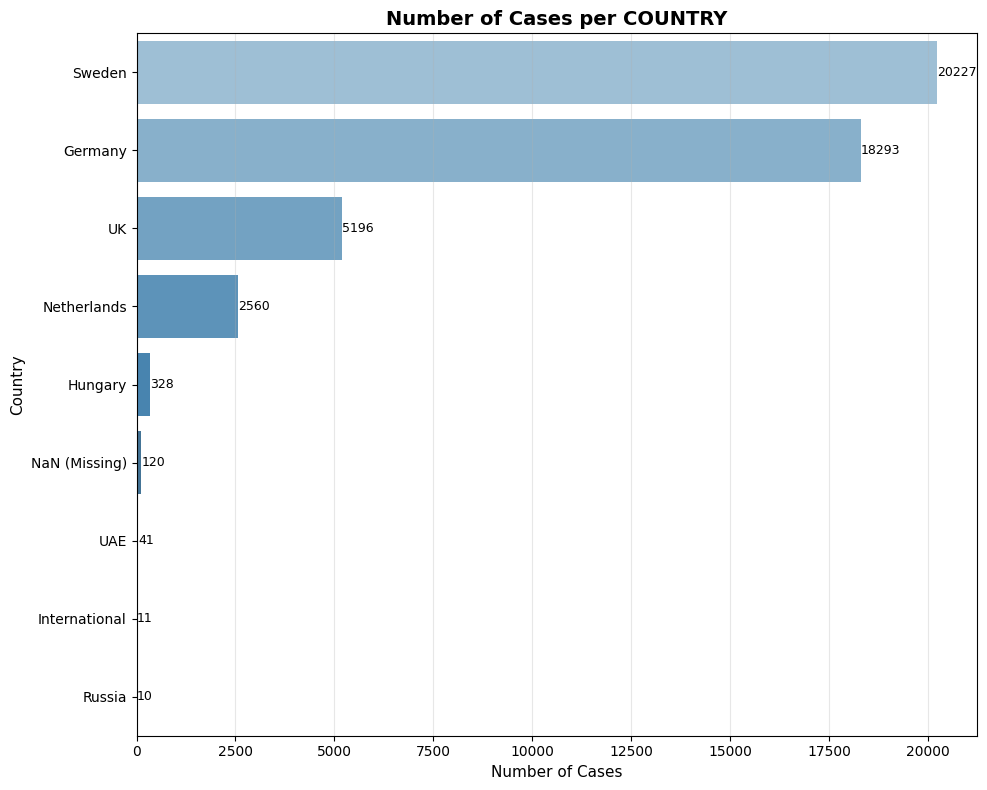

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count the number of cases per COUNTRY (including NaN)
country_counts = master_df_1['SL_COUNTRY'].value_counts(dropna=False).reset_index()
country_counts.columns = ['SL_COUNTRY', 'case_count']

# Replace NaN with a visible label
country_counts['SL_COUNTRY'] = country_counts['SL_COUNTRY'].fillna('NaN (Missing)')

# Sort by case count for better visualization
country_counts = country_counts.sort_values('case_count', ascending=False)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create horizontal bar plot with seaborn
sns.barplot(
    data=country_counts,
    y='SL_COUNTRY',
    x='case_count',
    palette='Blues_d',
    ax=ax
)

# Add count labels at the end of bars (without using zip)
for i in range(len(country_counts)):
    country = country_counts['SL_COUNTRY'].iloc[i]
    count = country_counts['case_count'].iloc[i]
    ax.text(count + 5, i, str(count), va='center', fontsize=9)

# Customize the plot
ax.set_title('Number of Cases per COUNTRY', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Cases', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Generate cross-tabulation of countries and case types (including NaN)
country_case_counts = pd.crosstab(
    master_df_1['SL_COUNTRY'].fillna('NaN (Missing)'), 
    master_df_1['CASE_TYPE'], 
    dropna=False
)

# Add total cases per country
country_case_counts['Total Cases'] = country_case_counts.sum(axis=1)

# Sort by total cases descending
country_case_counts = country_case_counts.sort_values('Total Cases', ascending=False)

# Display as markdown table
print("\nNumber of Cases by Type per Country (including NaN):")
print(country_case_counts.to_markdown())

# Print total number of unique countries
print(f"\nTotal number of unique countries: {len(country_case_counts)}")


Number of Cases by Type per Country (including NaN):
| SL_COUNTRY    |   Asset and Reputation damage/loss |   Environment |   Information Security |   Operational loss |   Process Safety |   Safety |   nan |   Total Cases |
|:--------------|-----------------------------------:|--------------:|-----------------------:|-------------------:|-----------------:|---------:|------:|--------------:|
| Sweden        |                                860 |           990 |                      1 |                430 |             1374 |    16572 |     0 |         20227 |
| Germany       |                                918 |          1459 |                    250 |                 93 |             2424 |    13012 |   137 |         18293 |
| UK            |                                213 |           588 |                     20 |                181 |             1822 |     2335 |    37 |          5196 |
| Netherlands   |                                197 |           562 |                     

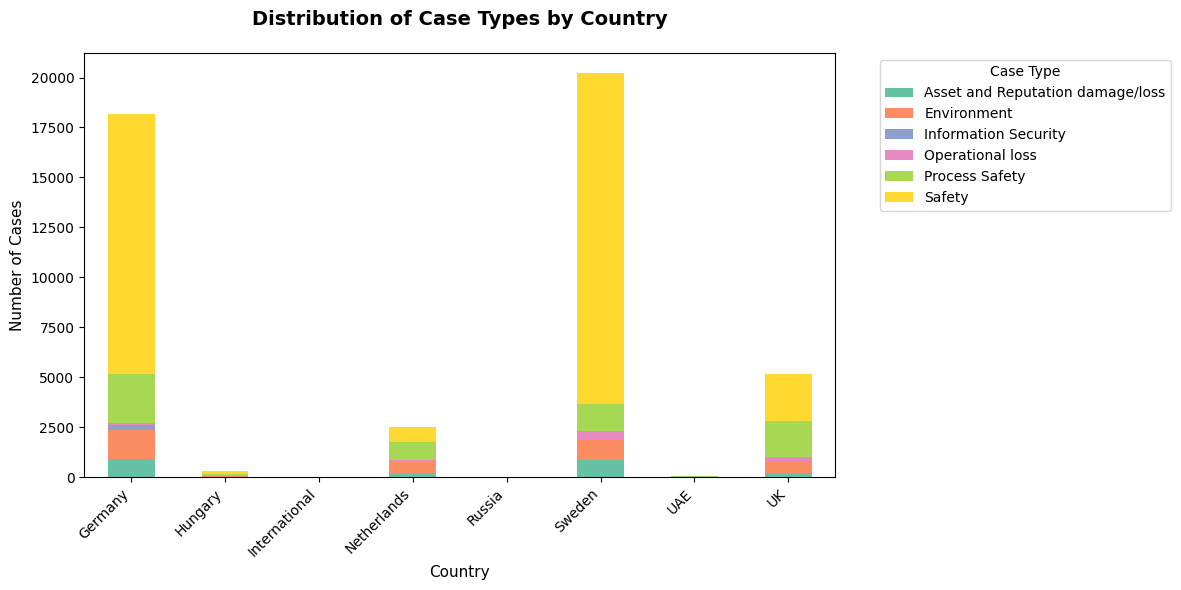

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate cross-tabulation
country_case_counts = pd.crosstab(master_df_1['SL_COUNTRY'], master_df_1['CASE_TYPE'])

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create stacked bar chart
country_case_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=sns.color_palette('Set2', n_colors=len(country_case_counts.columns))
)

# Customize the plot
ax.set_title('Distribution of Case Types by Country', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Number of Cases', fontsize=11)
ax.legend(title='Case Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Split into different datasets based on sl_country and save as csv files
countries = master_df_1['SL_COUNTRY'].dropna().unique()
output_dir = BASE_DIR / "Datasets" / "By_Country"
output_dir.mkdir(parents=True, exist_ok=True)

for country in countries:
    country_df = master_df_1[master_df_1['SL_COUNTRY'] == country]
    country_file = output_dir / f"RW_ACTUALS_{country.replace(' ', '_')}.csv"
    country_df.to_csv(country_file, index=False)
    print(f"Saved {country_df.shape[0]} records to {country_file}")

# Create combined English dataset (UK, UAE, International)
english_countries = ['UK', 'UAE', 'International']
english_df = master_df_1[master_df_1['SL_COUNTRY'].isin(english_countries)]
english_file = output_dir / "RW_ACTUALS_English.csv"
english_df.to_csv(english_file, index=False)
print(f"\n{'='*60}")
print(f"Saved combined English dataset: {english_df.shape[0]} records")
print(f"  - UK: {len(master_df_1[master_df_1['SL_COUNTRY'] == 'UK'])} records")
print(f"  - UAE: {len(master_df_1[master_df_1['SL_COUNTRY'] == 'UAE'])} records")
print(f"  - International: {len(master_df_1[master_df_1['SL_COUNTRY'] == 'International'])} records")
print(f"Location: {english_file}")
print(f"{'='*60}")

# Verify saved files
saved_files = list(output_dir.iterdir())
print(f"\nFiles saved in {output_dir}:")
for f in sorted(saved_files):
    print(f" - {f.name}")
print(f"Total files saved: {len(saved_files)}")

Saved 18293 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_Germany.csv
Saved 2560 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_Netherlands.csv
Saved 5196 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_UK.csv
Saved 20227 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_Sweden.csv
Saved 328 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_Hungary.csv
Saved 41 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_UAE.csv
Saved 11 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_International.csv
Saved 10 records to /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/By_Country/RW_ACTUALS_Russia.csv

Saved combine

In [17]:
# ============================================================
# RESET UTILITY - Iteration 1
# ============================================================

import os
import shutil
import gc
import torch

# Use PATHS from earlier configuration (already cross-platform)
EMBEDDINGS_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])

def list_cached_embeddings():
    """List all cached embedding files."""
    if os.path.exists(EMBEDDINGS_DIR):
        files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pkl')]
        if files:
            print(f"\n Cached embeddings in: {EMBEDDINGS_DIR}")
            print("-" * 60)
            for f in sorted(files):
                size_mb = os.path.getsize(os.path.join(EMBEDDINGS_DIR, f)) / 1024**2
                print(f"   • {f} ({size_mb:.1f} MB)")
            print("-" * 60)
            total_size = sum(os.path.getsize(os.path.join(EMBEDDINGS_DIR, f)) for f in files) / 1024**2
            print(f"   Total: {len(files)} files, {total_size:.1f} MB")
        else:
            print(" No cached embeddings found.")
    else:
        print(" Embeddings directory does not exist yet.")

def clear_specific_embedding(dataset_name):
    """Clear embedding for a specific dataset."""
    pattern = f"{dataset_name}_bert-base-cased_embeddings.pkl"
    pkl_file = os.path.join(EMBEDDINGS_DIR, pattern)
    if os.path.exists(pkl_file):
        os.remove(pkl_file)
        print(f" Deleted: {pattern}")
    else:
        print(f" Not found: {pattern}")

def clear_all_embeddings():
    """Clear ALL cached embeddings."""
    if os.path.exists(EMBEDDINGS_DIR):
        files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pkl')]
        for f in files:
            os.remove(os.path.join(EMBEDDINGS_DIR, f))
        print(f" Deleted {len(files)} embedding files.")
    else:
        print(" No embeddings to delete.")

def clear_results():
    """Clear all result files."""
    if os.path.exists(RESULTS_DIR):
        files = os.listdir(RESULTS_DIR)
        for f in files:
            filepath = os.path.join(RESULTS_DIR, f)
            if os.path.isfile(filepath):
                os.remove(filepath)
        print(f" Deleted {len(files)} result files from {RESULTS_DIR}")
    else:
        print(" No results to delete.")

def clear_gpu_memory():
    """Clear GPU memory cache."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        print(f" GPU memory cleared.")
        print(f"   Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.1f} MB")
        print(f"   Cached: {torch.cuda.memory_reserved(0) / 1024**2:.1f} MB")
    else:
        gc.collect()
        print(" Memory garbage collected (CPU mode).")

def complete_reset():
    """Complete reset - clear all embeddings, results, and memory."""
    print("\n" + "="*60)
    print("FULL RESET - ITERATION 1")
    print("="*60)
    clear_all_embeddings()
    clear_results()
    clear_gpu_memory()
    print("\n Full reset complete! You can now re-run all cells.")
    print("="*60)

# ============================================================
# SHOW CURRENT STATE
# ============================================================
print("="*60)
print("ITERATION 1 - RESTART UTILITY")
print("="*60)

list_cached_embeddings()

print("\n AVAILABLE COMMANDS:")
print("-" * 60)
print("  list_cached_embeddings()           - Show all cached files")
print("  clear_specific_embedding('german') - Delete one dataset's cache")
print("  clear_specific_embedding('uk')     - Delete one dataset's cache")
print("  clear_specific_embedding('english')- Delete one dataset's cache")
print("  clear_specific_embedding('sweden') - Delete one dataset's cache")
print("  clear_specific_embedding('netherlands') - Delete one dataset's cache")
print("  clear_specific_embedding('master_df_1') - Delete master dataset cache")
print("  clear_all_embeddings()             - Delete ALL embeddings")
print("  clear_results()                    - Delete all result files")
print("  clear_gpu_memory()                 - Free GPU/CPU memory")
print("  complete_reset()                  - Complete reset (all of above)")
print("-" * 60)
print("\n To regenerate embeddings, run the appropriate command above,")
print("    then re-run the dataset processing cells.")

# ============================================================
# UNCOMMENT ONE OF THESE LINES TO EXECUTE:
# ============================================================
# clear_specific_embedding('german')
# clear_specific_embedding('uk')
# clear_specific_embedding('english')
# clear_specific_embedding('sweden')
# clear_specific_embedding('netherlands')
# clear_specific_embedding('master_df_1')
# clear_all_embeddings()
# clear_results()
# clear_gpu_memory()
# full_reset()

ITERATION 1 - RESTART UTILITY

 Cached embeddings in: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased
------------------------------------------------------------
   • english_bert-base-cased_embeddings.pkl (20.8 MB)
   • german_bert-base-cased_embeddings.pkl (67.1 MB)
   • netherlands_bert-base-cased_embeddings.pkl (9.3 MB)
   • sweden_bert-base-cased_embeddings.pkl (61.2 MB)
   • uk_bert-base-cased_embeddings.pkl (20.6 MB)
------------------------------------------------------------
   Total: 5 files, 179.1 MB

 AVAILABLE COMMANDS:
------------------------------------------------------------
  list_cached_embeddings()           - Show all cached files
  clear_specific_embedding('german') - Delete one dataset's cache
  clear_specific_embedding('uk')     - Delete one dataset's cache
  clear_specific_embedding('english')- Delete one dataset's cache
  clear_specific_embedding('sweden') - Delete one dataset's cache
  clear_specif

In [18]:
complete_reset()


FULL RESET - ITERATION 1
 Deleted 5 embedding files.
 Deleted 7 result files from /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1
 Memory garbage collected (CPU mode).

 Full reset complete! You can now re-run all cells.


In [19]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # CHANGED: LinearSVC is MUCH faster than SVC for linear kernels
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import time

# ============================================================
# Check for GPU and set device
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" WARNING: Running on CPU - embedding generation will be SLOW!")
    print("   Consider using a GPU-enabled compute instance for faster processing.")

# ============================================================
# Initialize BERT model once (shared across all datasets)
# ============================================================
MODEL_NAME = 'bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()  # Set to evaluation mode

print(f"Model '{MODEL_NAME}' loaded successfully on {device}")

# ============================================================
# Generate BERT Embeddings (WITH CACHING)
# ============================================================
def generate_embeddings(df, dataset_name, embeddings_dir, max_length=256, batch_size=32):
    """
    Generate BERT embeddings for a dataset and save to disk.
    INCLUDES CACHING - skips if embeddings already exist.
    
    Parameters:
        df: DataFrame with 'TITLE', 'CASE_DESCRIPTION', and 'CASE_TYPE' columns
        dataset_name: String identifier for the dataset
        embeddings_dir: Directory to save embeddings
        max_length: Maximum sequence length for BERT (reduced to 256 for speed)
        batch_size: Batch size for embedding generation (increased to 32 for speed)
    
    Returns:
        str: Path to saved embeddings file
    """
    os.makedirs(embeddings_dir, exist_ok=True)
    pkl_file = os.path.join(embeddings_dir, f'{dataset_name}_{MODEL_NAME}_embeddings.pkl')
    
    # ============================================================
    # CACHING: Skip if embeddings already exist
    # ============================================================
    if os.path.exists(pkl_file):
        print(f"\n{'='*80}")
        print(f"STEP 1: EMBEDDINGS ALREADY EXIST - {dataset_name.upper()}")
        print(f"{'='*80}")
        print(f" Using cached embeddings: {pkl_file}")
        print(f"  (Delete this file to regenerate embeddings)")
        return pkl_file
    
    print(f"\n{'='*80}")
    print(f"STEP 1: GENERATING EMBEDDINGS - {dataset_name.upper()}")
    print(f"{'='*80}")
    print(f"Dataset shape: {df.shape}")
    
    # Create binary labels
    df = df.copy()
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'].fillna('') + '. ' + df['CASE_DESCRIPTION'].fillna('')
    texts = df['text_features'].tolist()
    
    print(f"Generating embeddings for {len(texts)} samples...")
    print(f"Batch size: {batch_size}, Max length: {max_length}")
    
    # Estimate time
    batches = len(texts) // batch_size + 1
    if device.type == 'cuda':
        est_time = batches * 0.1  # ~0.1s per batch on GPU
    else:
        est_time = batches * 2.0  # ~2s per batch on CPU
    print(f"Estimated time: {est_time/60:.1f} minutes ({batches} batches)")
    
    start_time = time.time()
    
    # Generate embeddings
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding {dataset_name}"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                          max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
            # Use CLS token embedding
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
    
    elapsed = time.time() - start_time
    print(f"Embedding generation completed in {elapsed/60:.1f} minutes")
    
    X = np.array(embeddings)
    y = df['binary_label'].values
    
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Embedding dimension: {X_train.shape[1]}")
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'metadata': {
            'model': MODEL_NAME,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'generation_time_minutes': elapsed/60
        }
    }
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"Embeddings saved: {pkl_file}")
    return pkl_file


# ============================================================
# Train SVM and Evaluate (OPTIMIZED with LinearSVC)
# ============================================================
def train_svm_and_evaluate(embeddings_path, dataset_name, results_dir):
    """
    Load embeddings, train LinearSVC (FAST), and evaluate.
    
    LinearSVC is 10-100x FASTER than SVC(kernel='linear') for large datasets!
    - SVC: O(n²) to O(n³) complexity
    - LinearSVC: O(n) complexity using liblinear
    
    Parameters:
        embeddings_path: Path to the embeddings pickle file
        dataset_name: String identifier for the dataset
        results_dir: Directory to save results
    
    Returns:
        dict: Results including metrics
    """
    print(f"\n{'='*80}")
    print(f"STEP 2: TRAINING LinearSVC (FAST) - {dataset_name.upper()}")
    print(f"{'='*80}")
    
    # Load embeddings
    with open(embeddings_path, 'rb') as f:
        data = pickle.load(f)
    
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    print(f"Loaded embeddings from: {embeddings_path}")
    print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
    
    # ============================================================
    # OPTIMIZED: Use LinearSVC instead of SVC
    # LinearSVC is MUCH faster for linear kernels (10-100x speedup)
    # dual=False is faster when n_samples > n_features
    # ============================================================
    print("Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...")
    
    start_time = time.time()
    
    # LinearSVC with optimized settings
    svm_model = LinearSVC(
        class_weight='balanced',  # Handle class imbalance
        dual='auto',              # Auto-select based on n_samples vs n_features
        max_iter=10000,           # Ensure convergence
        random_state=42,
        tol=1e-4,                 # Tolerance for stopping
        C=1.0                     # Regularization parameter
    )
    svm_model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    print(f"✓ LinearSVC training completed in {train_time:.1f} seconds")
    
    # Predict
    y_pred = svm_model.predict(X_test)
    
    # Calculate metrics
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    total = TN + FP + FN + TP
    
    accuracy = (TP + TN) / total
    precision_ps = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_ps = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_ps = 2 * (precision_ps * recall_ps) / (precision_ps + recall_ps) if (precision_ps + recall_ps) > 0 else 0
    
    precision_nps = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_nps = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_nps = 2 * (precision_nps * recall_nps) / (precision_nps + recall_nps) if (precision_nps + recall_nps) > 0 else 0
    
    macro_f1 = (f1_ps + f1_nps) / 2
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    # Print results
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-PS', 'Process Safety']))
    
    print(f"\nConfusion Matrix:")
    print(f"  TN={TN:,}  FP={FP:,}")
    print(f"  FN={FN:,}  TP={TP:,}")
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"FNR: {fnr:.4f}")
    
    return {
        'dataset': dataset_name,
        'model': MODEL_NAME,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'total': total,
        'accuracy': accuracy,
        'precision_ps': precision_ps,
        'recall_ps': recall_ps,
        'f1_ps': f1_ps,
        'precision_nps': precision_nps,
        'recall_nps': recall_nps,
        'f1_nps': f1_nps,
        'macro_precision': (precision_ps + precision_nps) / 2,
        'macro_recall': (recall_ps + recall_nps) / 2,
        'macro_f1': macro_f1,
        'fpr': fpr,
        'fnr': fnr,
        'confusion_matrix': cm,
        'train_time_seconds': train_time
    }


# ============================================================
# Save Results (Confusion Matrix Plot)
# ============================================================
def save_results(metrics, results_dir):
    """
    Save confusion matrix plot and results.
    
    Parameters:
        metrics: Dictionary containing evaluation metrics
        results_dir: Directory to save results
    
    Returns:
        str: Path to saved plot
    """
    print(f"\n{'='*80}")
    print(f"STEP 3: SAVING RESULTS - {metrics['dataset'].upper()}")
    print(f"{'='*80}")
    
    os.makedirs(results_dir, exist_ok=True)
    
    # Create confusion matrix plot
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = metrics['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
                yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 14, 'fontweight': 'bold'})
    
    model_short = MODEL_NAME.replace('/', '_').replace('-', '_')
    dataset_name = metrics['dataset']
    
    title_text = f"Confusion Matrix: {dataset_name.upper()} - {MODEL_NAME}\n"
    title_text += f"Accuracy: {metrics['accuracy']:.4f} | Macro F1: {metrics['macro_f1']:.4f} | FNR: {metrics['fnr']:.4f}"
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    
    plt.tight_layout()
    
    plot_path = os.path.join(results_dir, f'cm_{dataset_name}_{model_short}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved: {plot_path}")
    return plot_path


# ============================================================
# Combined Pipeline
# ============================================================
def run_full_pipeline(df, dataset_name, embeddings_dir, results_dir):
    """
    Run the complete pipeline: embeddings -> SVM -> save results.
    """
    # Step 1: Generate embeddings (with caching)
    embeddings_path = generate_embeddings(df, dataset_name, embeddings_dir)
    
    # Step 2: Train SVM and evaluate
    metrics = train_svm_and_evaluate(embeddings_path, dataset_name, results_dir)
    
    # Step 3: Save results
    plot_path = save_results(metrics, results_dir)
    
    metrics['embeddings_path'] = embeddings_path
    metrics['plot_path'] = plot_path
    
    print(f"\n{'='*80}")
    print(f"PIPELINE COMPLETE: {dataset_name.upper()}")
    print(f"{'='*80}\n")
    
    return metrics

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using device: cpu
   Consider using a GPU-enabled compute instance for faster processing.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Model 'bert-base-cased' loaded successfully on cpu


In [20]:
# ============================================================
# Configuration and Setup
# ============================================================

# Use PATHS from earlier configuration cell - they're already set up
# These are already created from the config cell above
EMBEDDINGS_DIR = PATHS['embeddings']  # Already includes the iteration and model path
RESULTS_DIR = PATHS['results']
BY_COUNTRY_DIR = BASE_DIR / "Datasets" / "By_Country"
MASTER_PATH = PATHS['iteration_output'] / 'master_df_1.csv'

# Create directories
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
BY_COUNTRY_DIR.mkdir(parents=True, exist_ok=True)

# Store results for all datasets
all_results = []

print(f"Configuration complete!")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Configuration complete!
Embeddings directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased
Results directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1


#### Process German Dataset

/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_12699/2300706938.py:5: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  german_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_Germany.csv')



STEP 1: GENERATING EMBEDDINGS - GERMAN
Dataset shape: (18293, 36)
Generating embeddings for 18293 samples...
Batch size: 32, Max length: 256
Estimated time: 19.1 minutes (572 batches)


Embedding german: 100%|██████████| 572/572 [13:49<00:00,  1.45s/it]


Embedding generation completed in 13.8 minutes
Training set: 14634 samples
Test set: 3659 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/german_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - GERMAN
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/german_bert-base-cased_embeddings.pkl
Training samples: 14634, Test samples: 3659
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
✓ LinearSVC training completed in 5.1 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.95      0.79      0.86      3174
Process Safety       0.35      0.75      0.48       485

      accuracy                           0.78      3659
     macro avg       0.65      0.77      0.67      3659
  weighted avg       0.87 

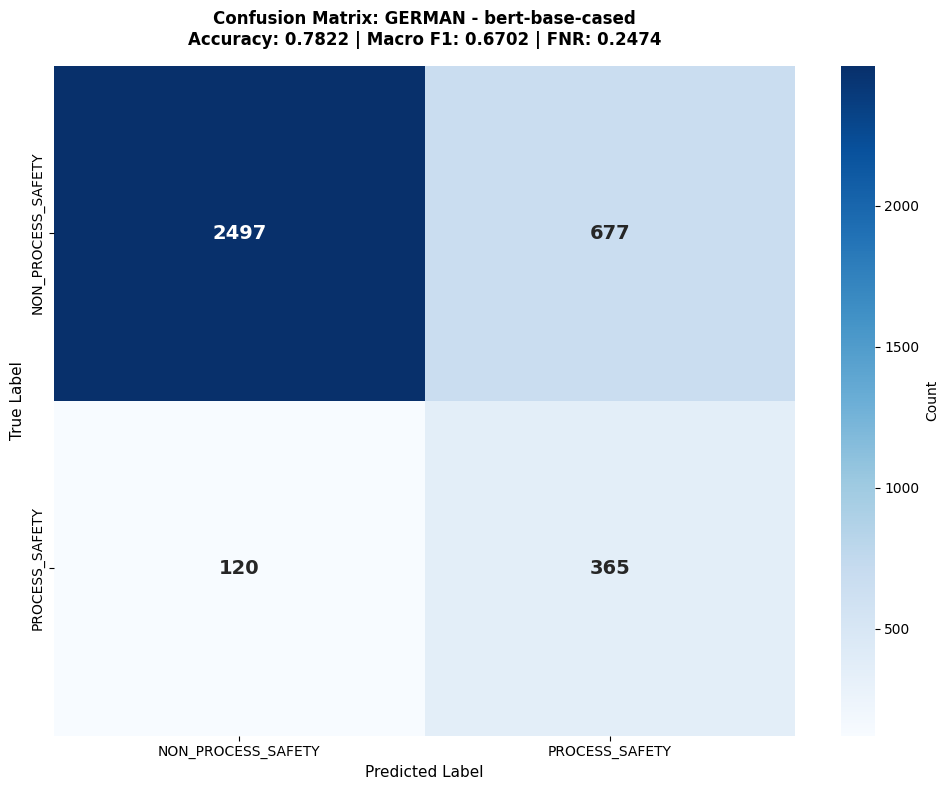

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_german_bert_base_cased.png

PIPELINE COMPLETE: GERMAN

German dataset processing complete!


In [21]:
# ============================================================
# German Dataset
# ============================================================

german_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_Germany.csv')

german_results = run_full_pipeline(
    df=german_df,
    dataset_name='german',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(german_results)
print(f"German dataset processing complete!")

#### Process UK Dataset


STEP 1: GENERATING EMBEDDINGS - UK
Dataset shape: (5196, 36)
Generating embeddings for 5196 samples...
Batch size: 32, Max length: 256
Estimated time: 5.4 minutes (163 batches)


Embedding uk: 100%|██████████| 163/163 [04:12<00:00,  1.55s/it]


Embedding generation completed in 4.2 minutes
Training set: 4156 samples
Test set: 1040 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/uk_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - UK
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/uk_bert-base-cased_embeddings.pkl
Training samples: 4156, Test samples: 1040
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
✓ LinearSVC training completed in 0.8 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.88      0.79      0.83       675
Process Safety       0.67      0.80      0.73       365

      accuracy                           0.79      1040
     macro avg       0.77      0.79      0.78      1040
  weighted avg       0.81      0.79      

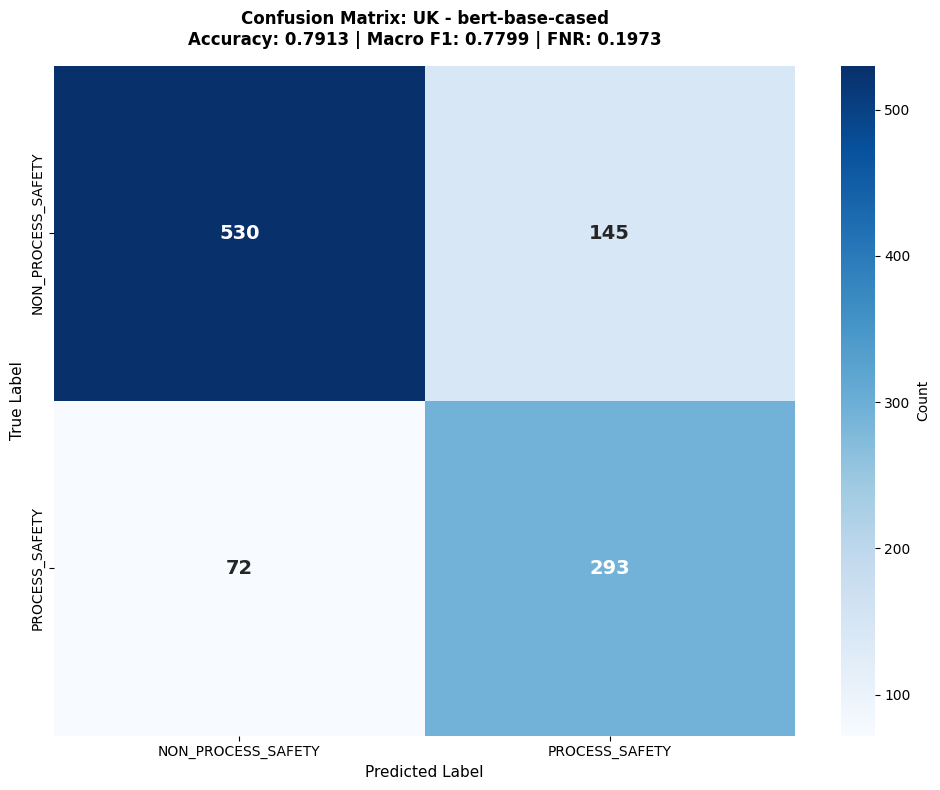

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_uk_bert_base_cased.png

PIPELINE COMPLETE: UK

UK dataset processing complete!


In [22]:
# ============================================================
# UK Dataset
# ============================================================

uk_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_UK.csv')

uk_results = run_full_pipeline(
    df=uk_df,
    dataset_name='uk',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(uk_results)
print(f"UK dataset processing complete!")

#### Process English Dataset (UK + UAE + International)


STEP 1: GENERATING EMBEDDINGS - ENGLISH
Dataset shape: (5248, 36)
Generating embeddings for 5248 samples...
Batch size: 32, Max length: 256
Estimated time: 5.5 minutes (165 batches)


Embedding english: 100%|██████████| 164/164 [04:29<00:00,  1.64s/it]


Embedding generation completed in 4.5 minutes
Training set: 4198 samples
Test set: 1050 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/english_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - ENGLISH
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/english_bert-base-cased_embeddings.pkl
Training samples: 4198, Test samples: 1050
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
✓ LinearSVC training completed in 0.9 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.88      0.78      0.83       677
Process Safety       0.67      0.81      0.73       373

      accuracy                           0.79      1050
     macro avg       0.78      0.79      0.78      1050
  weighted avg       0.81 

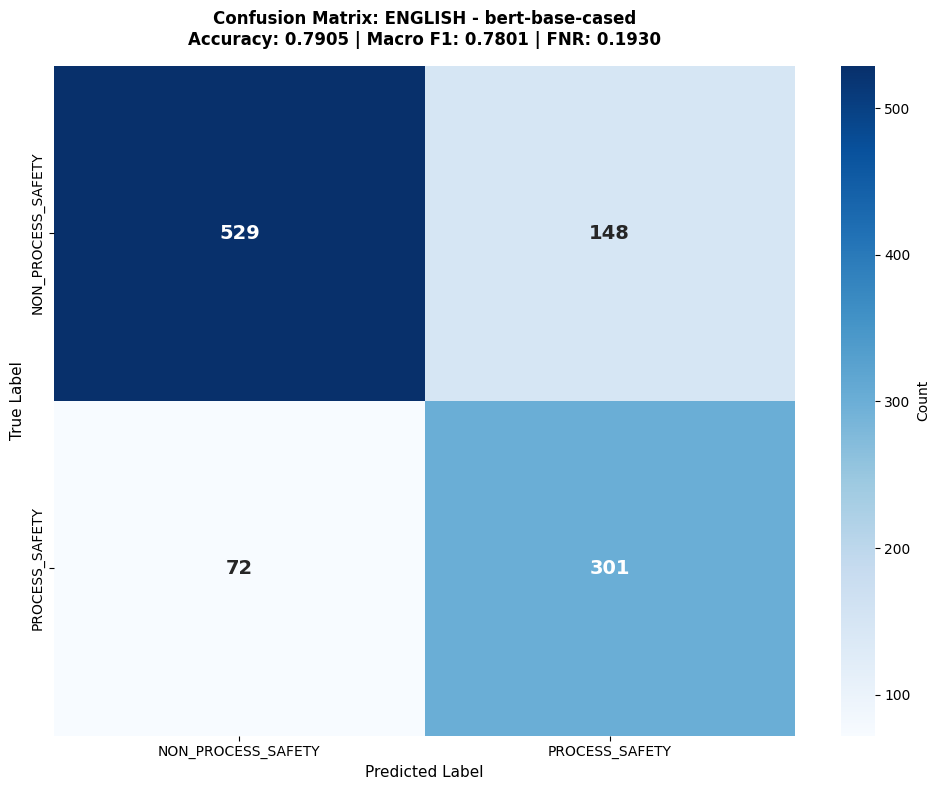

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_english_bert_base_cased.png

PIPELINE COMPLETE: ENGLISH

English dataset processing complete!


In [23]:
# ============================================================
# English Dataset (UK + UAE + International)
# ============================================================

english_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_English.csv')

english_results = run_full_pipeline(
    df=english_df,
    dataset_name='english',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(english_results)
print(f"English dataset processing complete!")

####  Process Sweden Dataset


STEP 1: GENERATING EMBEDDINGS - SWEDEN
Dataset shape: (20227, 36)
Generating embeddings for 20227 samples...
Batch size: 32, Max length: 256
Estimated time: 21.1 minutes (633 batches)


Embedding sweden: 100%|██████████| 633/633 [08:03<00:00,  1.31it/s]


Embedding generation completed in 8.1 minutes
Training set: 16181 samples
Test set: 4046 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/sweden_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - SWEDEN
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/sweden_bert-base-cased_embeddings.pkl
Training samples: 16181, Test samples: 4046
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
✓ LinearSVC training completed in 5.0 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.97      0.80      0.88      3771
Process Safety       0.20      0.70      0.31       275

      accuracy                           0.79      4046
     macro avg       0.59      0.75      0.59      4046
  weighted avg       0.92  

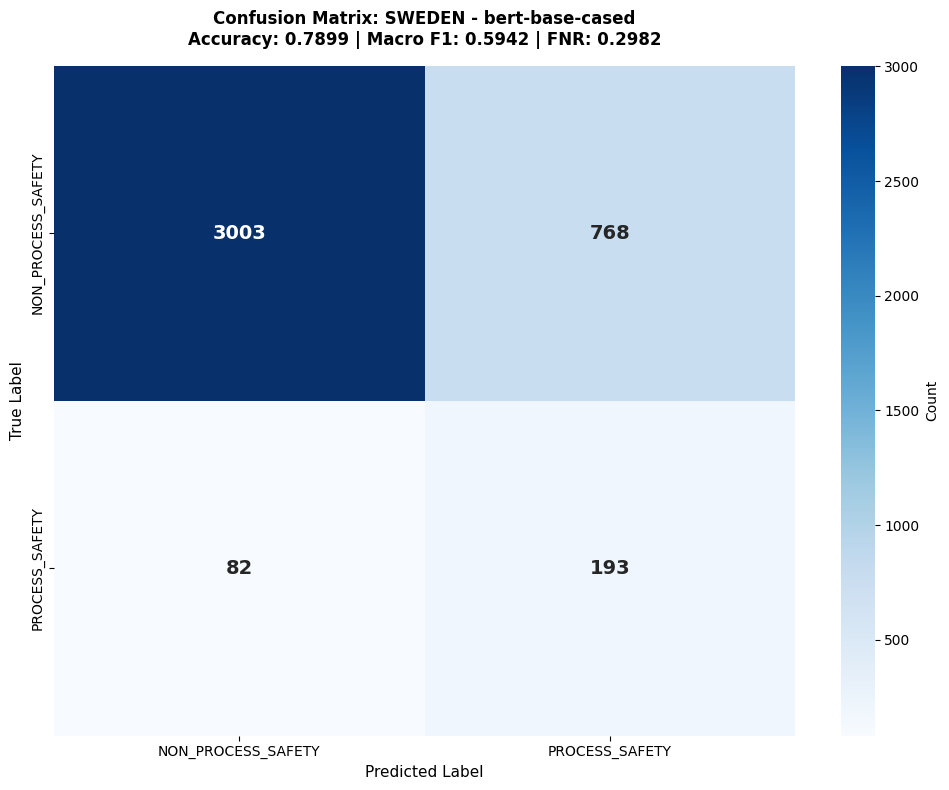

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_sweden_bert_base_cased.png

PIPELINE COMPLETE: SWEDEN

Sweden dataset processing complete!


In [24]:
# ============================================================
# Sweden Dataset
# ============================================================

sweden_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_Sweden.csv')

sweden_results = run_full_pipeline(
    df=sweden_df,
    dataset_name='sweden',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(sweden_results)
print(f"Sweden dataset processing complete!")

#### Process Netherlands Dataset


STEP 1: GENERATING EMBEDDINGS - NETHERLANDS
Dataset shape: (2560, 36)
Generating embeddings for 2560 samples...
Batch size: 32, Max length: 256
Estimated time: 2.7 minutes (81 batches)


Embedding netherlands: 100%|██████████| 80/80 [02:37<00:00,  1.97s/it]


Embedding generation completed in 2.6 minutes
Training set: 2048 samples
Test set: 512 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - NETHERLANDS
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl
Training samples: 2048, Test samples: 512
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
✓ LinearSVC training completed in 0.4 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.84      0.79      0.81       333
Process Safety       0.65      0.72      0.68       179

      accuracy                           0.77       512
     macro avg       0.74      0.76      0.75       512
  weighted avg  

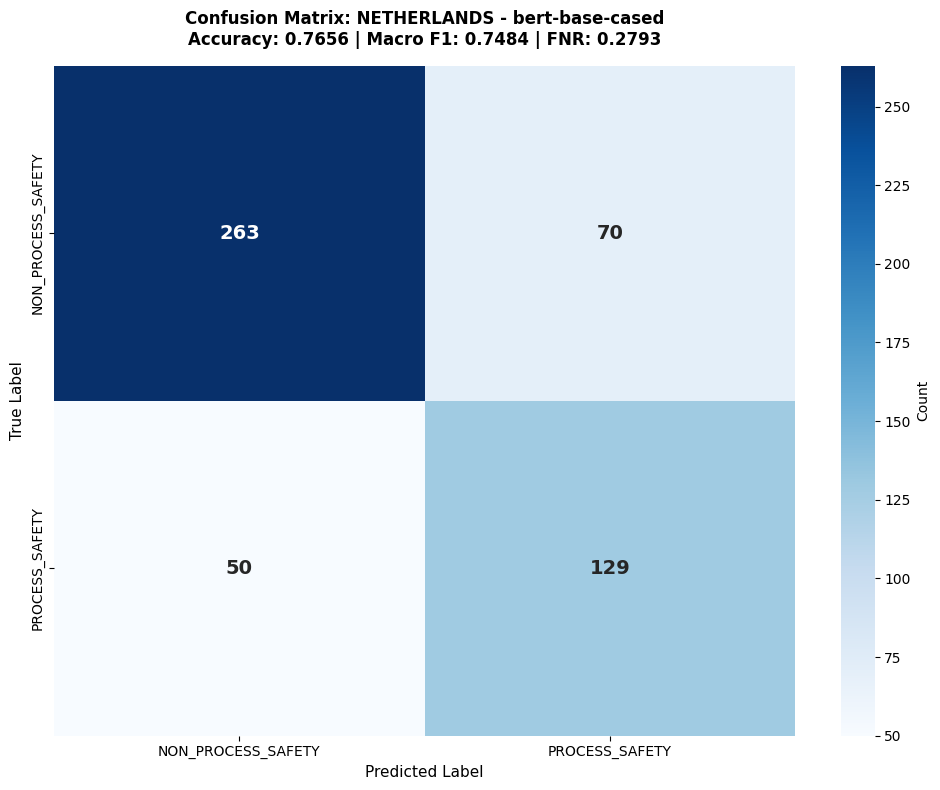

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_netherlands_bert_base_cased.png

PIPELINE COMPLETE: NETHERLANDS

Netherlands dataset processing complete!


In [25]:
# ============================================================
# Netherlands Dataset
# ============================================================

netherlands_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_Netherlands.csv')

netherlands_results = run_full_pipeline(
    df=netherlands_df,
    dataset_name='netherlands',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(netherlands_results)
print(f"Netherlands dataset processing complete!")

#### Process Master Dataset (All Countries Combined)

In [26]:
# Clear corrupted master_df_1 embeddings if they exist
import shutil
master_embedding_file = EMBEDDINGS_DIR / 'master_df_1_bert-base-cased_embeddings.pkl'
if master_embedding_file.exists():
    master_embedding_file.unlink()
    print(f"Deleted corrupted embedding file: {master_embedding_file}")
else:
    print("No corrupted embedding file found")

No corrupted embedding file found



STEP 1: GENERATING EMBEDDINGS - MASTER_DF_1
Dataset shape: (46786, 36)
Generating embeddings for 46786 samples...
Batch size: 32, Max length: 256
Estimated time: 48.8 minutes (1463 batches)


Embedding master_df_1: 100%|██████████| 1463/1463 [38:23<00:00,  1.57s/it]


Embedding generation completed in 38.4 minutes
Training set: 37428 samples
Test set: 9358 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/master_df_1_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - MASTER_DF_1
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/master_df_1_bert-base-cased_embeddings.pkl
Training samples: 37428, Test samples: 9358
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
✓ LinearSVC training completed in 12.5 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.94      0.76      0.84      8020
Process Safety       0.34      0.72      0.46      1338

      accuracy                           0.76      9358
     macro avg       0.64      0.74      0.65      9358
  weighted

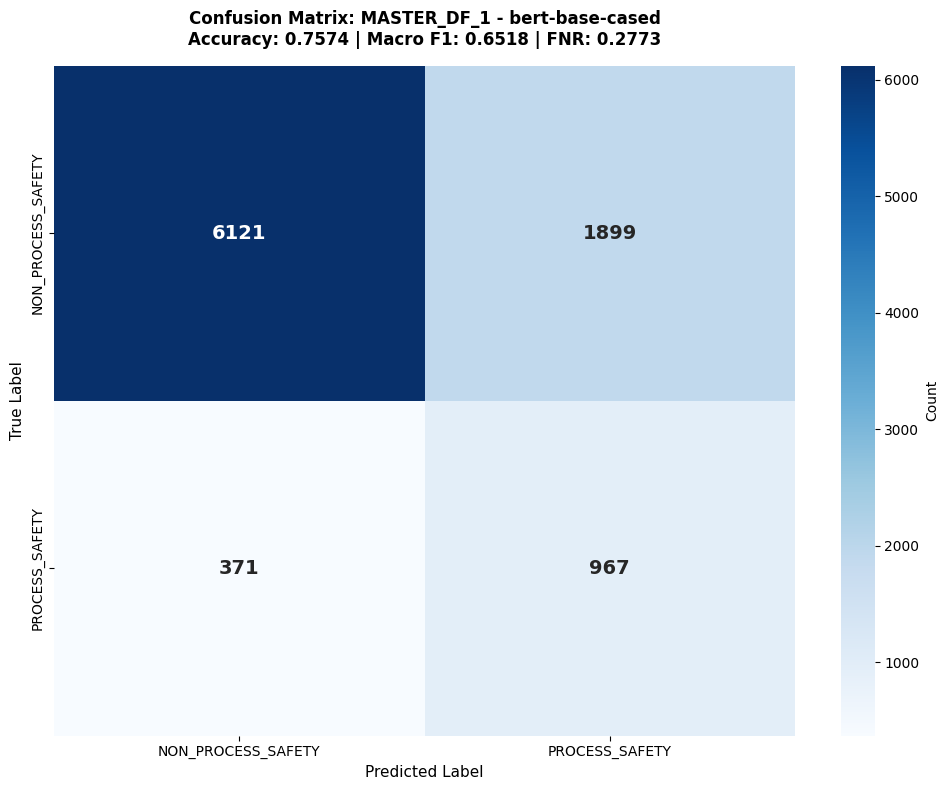

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_master_df_1_bert_base_cased.png

PIPELINE COMPLETE: MASTER_DF_1


 Master dataset processing complete!


In [27]:
# ============================================================
# Master Dataset
# ============================================================

master_df = pd.read_csv(str(MASTER_PATH), low_memory=False)

master_results = run_full_pipeline(
    df=master_df,
    dataset_name='master_df_1',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(master_results)
print(f"\n Master dataset processing complete!")

## Summary Report

In [28]:
# ============================================================
# Generate Summary Report
# ============================================================

print(f"\n\n{'#'*100}")
print(f"{'ITERATION 1 - COMPLETE SUMMARY REPORT':^100}")
print(f"{'#'*100}\n")

# Create summary DataFrame
results_df = pd.DataFrame(all_results)

# ============================================================
# Confusion Matrix Summary
# ============================================================
print(f"\n{'CONFUSION MATRIX SUMMARY':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'TN':>10} {'FP':>10} {'FN':>10} {'TP':>10} {'Total':>12} {'Accuracy':>12} {'Macro F1':>12}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    print(f"{row['dataset'].upper():<15} {row['TN']:>10,} {row['FP']:>10,} {row['FN']:>10,} {row['TP']:>10,} {row['total']:>12,} {row['accuracy']:>12.4f} {row['macro_f1']:>12.4f}")
print(f"{'='*100}\n")

# ============================================================
# Per-Class Metrics (Classification Report Style)
# ============================================================
print(f"\n{'PER-CLASS METRICS (sklearn classification_report style)':^100}")
print(f"{'='*100}")

for _, row in results_df.iterrows():
    dataset = row['dataset'].upper()
    support_nps = row['TN'] + row['FP']  # Actual NPS samples
    support_ps = row['FN'] + row['TP']    # Actual PS samples
    total = row['total']
    
    # Weighted averages
    weighted_precision = (row['precision_nps'] * support_nps + row['precision_ps'] * support_ps) / total
    weighted_recall = (row['recall_nps'] * support_nps + row['recall_ps'] * support_ps) / total
    weighted_f1 = (row['f1_nps'] * support_nps + row['f1_ps'] * support_ps) / total
    
    # Macro averages (already have macro_f1)
    macro_precision = (row['precision_nps'] + row['precision_ps']) / 2
    macro_recall = (row['recall_nps'] + row['recall_ps']) / 2
    
    print(f"\n┌─────────────────────────────────────────────────────────────────────────────────────────────────┐")
    print(f"│ {dataset:^95} │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Class':<20} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}               │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Non-Process Safety':<20} {row['precision_nps']:>12.4f} {row['recall_nps']:>12.4f} {row['f1_nps']:>12.4f} {support_nps:>12,}               │")
    print(f"│ {'Process Safety':<20} {row['precision_ps']:>12.4f} {row['recall_ps']:>12.4f} {row['f1_ps']:>12.4f} {support_ps:>12,}               │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Accuracy':<20} {'':>12} {'':>12} {row['accuracy']:>12.4f} {total:>12,}               │")
    print(f"│ {'Macro Avg':<20} {macro_precision:>12.4f} {macro_recall:>12.4f} {row['macro_f1']:>12.4f} {total:>12,}               │")
    print(f"│ {'Weighted Avg':<20} {weighted_precision:>12.4f} {weighted_recall:>12.4f} {weighted_f1:>12.4f} {total:>12,}               │")
    print(f"└─────────────────────────────────────────────────────────────────────────────────────────────────┘")

print(f"\n{'='*100}\n")

# ============================================================
# Detailed Metrics Summary Table
# ============================================================
print(f"\n{'DETAILED METRICS BY DATASET':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<12} {'Prec_NPS':>10} {'Rec_NPS':>10} {'F1_NPS':>10} {'Prec_PS':>10} {'Rec_PS':>10} {'F1_PS':>10} {'FPR':>10} {'FNR':>10}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    print(f"{row['dataset'].upper():<12} {row['precision_nps']:>10.4f} {row['recall_nps']:>10.4f} {row['f1_nps']:>10.4f} {row['precision_ps']:>10.4f} {row['recall_ps']:>10.4f} {row['f1_ps']:>10.4f} {row['fpr']:>10.4f} {row['fnr']:>10.4f}")
print(f"{'='*100}\n")

# ============================================================
# Error Rate Analysis
# ============================================================
print(f"\n{'ERROR RATE ANALYSIS':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'Error Rate':>12} {'FPR':>12} {'FNR':>12} {'PS Missed':>15} {'NPS Misclass.':>15}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    error_rate = 1 - row['accuracy']
    ps_missed = row['FN']  # Process Safety incidents missed (False Negatives)
    nps_misclassified = row['FP']  # Non-PS incorrectly flagged as PS (False Positives)
    print(f"{row['dataset'].upper():<15} {error_rate:>12.4f} {row['fpr']:>12.4f} {row['fnr']:>12.4f} {ps_missed:>15,} {nps_misclassified:>15,}")
print(f"{'='*100}\n")

# ============================================================
# Class Imbalance Analysis
# ============================================================
print(f"\n{'CLASS IMBALANCE ANALYSIS':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'Total':>10} {'NPS Count':>12} {'PS Count':>12} {'NPS %':>10} {'PS %':>10} {'Imbalance Ratio':>18}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    nps_count = row['TN'] + row['FP']  # Actual NPS
    ps_count = row['FN'] + row['TP']    # Actual PS
    nps_pct = (nps_count / row['total']) * 100
    ps_pct = (ps_count / row['total']) * 100
    imbalance_ratio = max(nps_count, ps_count) / min(nps_count, ps_count) if min(nps_count, ps_count) > 0 else float('inf')
    print(f"{row['dataset'].upper():<15} {row['total']:>10,} {nps_count:>12,} {ps_count:>12,} {nps_pct:>9.1f}% {ps_pct:>9.1f}% {imbalance_ratio:>17.2f}:1")
print(f"{'='*100}\n")

# ============================================================
# Key Observations
# ============================================================
print(f"\n{'KEY OBSERVATIONS':^100}")
print(f"{'='*100}")
print(f"\n  Performance Metrics:")
print(f"  • Total datasets processed: {len(results_df)}")
print(f"  • Best Macro F1: {results_df['macro_f1'].max():.4f} ({results_df.loc[results_df['macro_f1'].idxmax(), 'dataset'].upper()})")
print(f"  • Worst Macro F1: {results_df['macro_f1'].min():.4f} ({results_df.loc[results_df['macro_f1'].idxmin(), 'dataset'].upper()})")
print(f"  • Average Macro F1: {results_df['macro_f1'].mean():.4f}")
print(f"  • Average Accuracy: {results_df['accuracy'].mean():.4f}")

print(f"\n  Error Rates (Critical for Safety):")
print(f"  • Lowest FNR (best - fewest PS incidents missed): {results_df['fnr'].min():.4f} ({results_df.loc[results_df['fnr'].idxmin(), 'dataset'].upper()})")
print(f"  • Highest FNR (worst - most PS incidents missed): {results_df['fnr'].max():.4f} ({results_df.loc[results_df['fnr'].idxmax(), 'dataset'].upper()})")
print(f"  • Average FNR: {results_df['fnr'].mean():.4f}")
print(f"  • Average FPR: {results_df['fpr'].mean():.4f}")

print(f"\n  Precision-Recall Trade-off:")
best_ps_precision_idx = results_df['precision_ps'].idxmax()
best_ps_recall_idx = results_df['recall_ps'].idxmax()
print(f"  • Best PS Precision: {results_df['precision_ps'].max():.4f} ({results_df.loc[best_ps_precision_idx, 'dataset'].upper()})")
print(f"  • Best PS Recall: {results_df['recall_ps'].max():.4f} ({results_df.loc[best_ps_recall_idx, 'dataset'].upper()})")
print(f"  • Average PS Precision: {results_df['precision_ps'].mean():.4f}")
print(f"  • Average PS Recall: {results_df['recall_ps'].mean():.4f}")
print(f"{'='*100}\n")

# ============================================================
# Comparison with Baseline
# ============================================================
print(f"\n{'COMPARISON WITH ITERATION 0 BASELINE':^100}")
print(f"{'='*100}")
print(f"Iteration 0 Baseline (bert-base-uncased, English only): Macro F1 = 0.766")
print(f"RQ1 Target: Macro F1 ≥ 0.81 (+5 percentage points improvement)\n")
for _, row in results_df.iterrows():
    improvement = row['macro_f1'] - 0.766
    status = " TARGET MET" if row['macro_f1'] >= 0.81 else "✗ Below Target"
    print(f"  {row['dataset'].upper():<15}: Macro F1 = {row['macro_f1']:.4f} (Δ = {improvement:+.4f}) {status}")

# Summary statistics
met_target = (results_df['macro_f1'] >= 0.81).sum()
print(f"\n  Summary: {met_target}/{len(results_df)} datasets met the RQ1 target (≥0.81 Macro F1)")
print(f"{'='*100}\n")

# ============================================================
# Save Results
# ============================================================
summary_file = os.path.join(RESULTS_DIR, 'iteration_1_summary.csv')
results_df.to_csv(summary_file, index=False)
print(f"Summary saved to: {summary_file}")

# ============================================================
# Section 9: Markdown Tables for LaTeX/Thesis
# ============================================================
print(f"\n\n{'MARKDOWN TABLES (for LaTeX/Thesis)':^100}")
print(f"{'='*100}\n")

print("Table 1: Confusion Matrix Summary")
display_cols = ['dataset', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'macro_f1']
print(results_df[display_cols].to_markdown(index=False, floatfmt='.4f'))

print("\n\nTable 2: Per-Class Precision, Recall, F1-Score")
class_metrics_cols = ['dataset', 'precision_nps', 'recall_nps', 'f1_nps', 'precision_ps', 'recall_ps', 'f1_ps']
print(results_df[class_metrics_cols].to_markdown(index=False, floatfmt='.4f'))

print("\n\nTable 3: Error Rates")
error_cols = ['dataset', 'fpr', 'fnr']
results_df['error_rate'] = 1 - results_df['accuracy']
error_display = results_df[['dataset', 'error_rate', 'fpr', 'fnr']].copy()
print(error_display.to_markdown(index=False, floatfmt='.4f'))

print(f"\n\n{'='*100}")
print(f"{'ITERATION 1 PIPELINE COMPLETE':^100}")
print(f"{'='*100}")



####################################################################################################
                               ITERATION 1 - COMPLETE SUMMARY REPORT                                
####################################################################################################


                                      CONFUSION MATRIX SUMMARY                                      
Dataset                 TN         FP         FN         TP        Total     Accuracy     Macro F1
----------------------------------------------------------------------------------------------------
GERMAN               2,497        677        120        365        3,659       0.7822       0.6702
UK                     530        145         72        293        1,040       0.7913       0.7799
ENGLISH                529        148         72        301        1,050       0.7905       0.7801
SWEDEN               3,003        768         82        193        4,046       0.7899       0.5